# P6-C AI Prediction Models

This notebook contains two separate prediction tasks:

1. Student Training Completion Risk — classification
2. Vehicle Service Cost — regression

In [7]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.dummy import DummyClassifier, DummyRegressor

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2: Load the Student Course Completion Dataset

In [8]:
STUDENT_DATA_PATH = "Course_Completion_Prediction.csv"

df_students = pd.read_csv(STUDENT_DATA_PATH)

print("Student dataset shape:", df_students.shape)
print("\nColumns:")
print(df_students.columns.tolist())

print("\nTarget distribution:")
print(df_students["Completed"].value_counts())

display(df_students.head())

Student dataset shape: (100000, 40)

Columns:
['Student_ID', 'Name', 'Gender', 'Age', 'Education_Level', 'Employment_Status', 'City', 'Device_Type', 'Internet_Connection_Quality', 'Course_ID', 'Course_Name', 'Category', 'Course_Level', 'Course_Duration_Days', 'Instructor_Rating', 'Login_Frequency', 'Average_Session_Duration_Min', 'Video_Completion_Rate', 'Discussion_Participation', 'Time_Spent_Hours', 'Days_Since_Last_Login', 'Notifications_Checked', 'Peer_Interaction_Score', 'Assignments_Submitted', 'Assignments_Missed', 'Quiz_Attempts', 'Quiz_Score_Avg', 'Project_Grade', 'Progress_Percentage', 'Rewatch_Count', 'Enrollment_Date', 'Payment_Mode', 'Fee_Paid', 'Discount_Used', 'Payment_Amount', 'App_Usage_Percentage', 'Reminder_Emails_Clicked', 'Support_Tickets_Raised', 'Satisfaction_Rating', 'Completed']

Target distribution:
Completed
Not Completed    50970
Completed        49030
Name: count, dtype: int64


,Student_ID,Name,Gender,Age,Education_Level,Employment_Status,City,Device_Type,Internet_Connection_Quality,Course_ID,...,Enrollment_Date,Payment_Mode,Fee_Paid,Discount_Used,Payment_Amount,App_Usage_Percentage,Reminder_Emails_Clicked,Support_Tickets_Raised,Satisfaction_Rating,Completed
0,STU100000,Vihaan Patel,Male,19,Diploma,Student,Indore,Laptop,Medium,C102,...,01-06-2024,Scholarship,No,No,1740,49,3,4,3.5,Completed
1,STU100001,Arjun Nair,Female,17,Bachelor,Student,Delhi,Laptop,Low,C106,...,27-04-2025,Credit Card,Yes,No,6147,86,0,0,4.5,Not Completed
2,STU100002,Aditya Bhardwaj,Female,34,Master,Student,Chennai,Mobile,Medium,C101,...,20-01-2024,NetBanking,Yes,No,4280,85,1,0,5.0,Completed
3,STU100003,Krishna Singh,Female,29,Diploma,Employed,Surat,Mobile,High,C105,...,13-05-2025,UPI,Yes,No,3812,42,2,3,3.8,Completed
4,STU100004,Krishna Nair,Female,19,Master,Self-Employed,Lucknow,Laptop,Medium,C106,...,19-12-2024,Debit Card,Yes,Yes,5486,91,3,0,4.0,Completed


## Step 3: Define the Training-Risk Target and Features

The prediction target is whether a student is at risk of not completing the course.

Only learning/activity-related features are used.

Identifiers, demographic attributes, payment information, and outcome-leakage features are excluded.

In [9]:
# Students who did not complete the course are treated as "At Risk"
df_students["At_Risk"] = (
    df_students["Completed"] == "Not Completed"
).astype(int)

# Learning/activity features only
RISK_FEATURES = [
    "Login_Frequency",
    "Average_Session_Duration_Min",
    "Video_Completion_Rate",
    "Discussion_Participation",
    "Time_Spent_Hours",
    "Days_Since_Last_Login",
    "Notifications_Checked",
    "Peer_Interaction_Score",
    "Assignments_Submitted",
    "Assignments_Missed",
    "Quiz_Attempts",
    "Quiz_Score_Avg",
    "Rewatch_Count",
    "App_Usage_Percentage",
    "Reminder_Emails_Clicked",
    "Support_Tickets_Raised",
    "Satisfaction_Rating"
]

# These are intentionally NOT used:
# Student_ID, Name, Gender, Age, City, etc. -> personal/demographic data
# Progress_Percentage, Project_Grade -> possible outcome leakage
# Payment fields -> not learning activity
# Enrollment_Date -> not needed for the MVP risk model

assert all(
    col in df_students.columns for col in RISK_FEATURES
), "One or more risk features are missing."

X_student = df_students[RISK_FEATURES]
y_student = df_students["At_Risk"]

print("Number of features:", len(RISK_FEATURES))
print("Feature list:")
print(RISK_FEATURES)

print("\nTarget distribution:")
print(
    y_student.value_counts()
    .rename(index={0: "Not At Risk", 1: "At Risk"})
)

print("\nMissing values in selected features:")
print(X_student.isna().sum().sum())

Number of features: 17
Feature list:
['Login_Frequency', 'Average_Session_Duration_Min', 'Video_Completion_Rate', 'Discussion_Participation', 'Time_Spent_Hours', 'Days_Since_Last_Login', 'Notifications_Checked', 'Peer_Interaction_Score', 'Assignments_Submitted', 'Assignments_Missed', 'Quiz_Attempts', 'Quiz_Score_Avg', 'Rewatch_Count', 'App_Usage_Percentage', 'Reminder_Emails_Clicked', 'Support_Tickets_Raised', 'Satisfaction_Rating']

Target distribution:
At_Risk
At Risk        50970
Not At Risk    49030
Name: count, dtype: int64

Missing values in selected features:
0


## Step 4: Student Training-Risk EDA

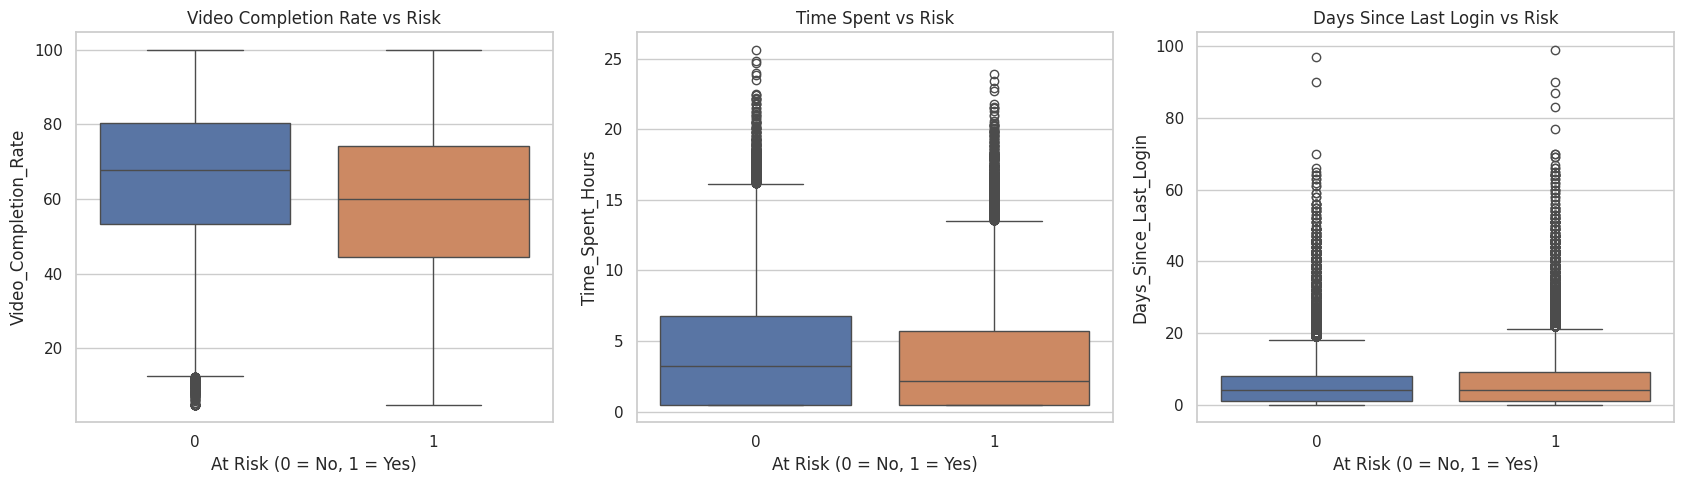

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.boxplot(
    x="At_Risk",
    y="Video_Completion_Rate",
    data=df_students,
    hue="At_Risk",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Video Completion Rate vs Risk")
axes[0].set_xlabel("At Risk (0 = No, 1 = Yes)")

sns.boxplot(
    x="At_Risk",
    y="Time_Spent_Hours",
    data=df_students,
    hue="At_Risk",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Time Spent vs Risk")
axes[1].set_xlabel("At Risk (0 = No, 1 = Yes)")

sns.boxplot(
    x="At_Risk",
    y="Days_Since_Last_Login",
    data=df_students,
    hue="At_Risk",
    legend=False,
    ax=axes[2]
)
axes[2].set_title("Days Since Last Login vs Risk")
axes[2].set_xlabel("At Risk (0 = No, 1 = Yes)")

plt.tight_layout()
plt.show()

## Step 5: Train the Student Training-Risk Model

In [11]:
# ---------------------------------------------------------
# Student train / validation / test split
# 70% train, 15% validation, 15% test
# ---------------------------------------------------------

X_train, X_temp, y_train, y_temp = train_test_split(
    X_student,
    y_student,
    test_size=0.30,
    random_state=42,
    stratify=y_student
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

# ---------------------------------------------------------
# Preprocessing
# ---------------------------------------------------------

student_preprocessor = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        RISK_FEATURES
    )
])

# ---------------------------------------------------------
# Logistic Regression
# ---------------------------------------------------------

student_model = Pipeline([
    ("preprocessor", student_preprocessor),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

student_model.fit(X_train, y_train)

# ---------------------------------------------------------
# Initial test evaluation using 0.50 threshold
# ---------------------------------------------------------

test_prob_default = student_model.predict_proba(X_test)[:, 1]
test_pred_default = (test_prob_default >= 0.50).astype(int)

print("\nStudent Training-Risk Model")
print("=" * 60)

print(
    "ROC-AUC:",
    round(roc_auc_score(y_test, test_prob_default), 3)
)

print(
    "Average Precision:",
    round(average_precision_score(y_test, test_prob_default), 3)
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        test_pred_default,
        target_names=["Not At Risk", "At Risk"],
        zero_division=0
    )
)

Train: (70000, 17)
Validation: (15000, 17)
Test: (15000, 17)

Student Training-Risk Model
ROC-AUC: 0.638
Average Precision: 0.632

Classification Report:
              precision    recall  f1-score   support

 Not At Risk       0.59      0.61      0.60      7355
     At Risk       0.61      0.60      0.60      7645

    accuracy                           0.60     15000
   macro avg       0.60      0.60      0.60     15000
weighted avg       0.60      0.60      0.60     15000



Step 6: Train the Student Prediction Suite (2 mode## Step 6: Deterministic Training-Risk Baseline

The ML model is not the only risk mechanism.

P6-C also requires a deterministic fallback that can work even when there is insufficient history or the ML model is unavailable.ls)

In [12]:
def training_risk_baseline(
    missing_attendance,
    unsigned_assessments,
    unmet_competencies
):
    """
    Deterministic fallback for the P6-C application.

    Each unmet condition contributes one risk point.
    """

    score = (
        int(missing_attendance > 0)
        + int(unsigned_assessments > 0)
        + int(unmet_competencies > 0)
    )

    if score >= 2:
        level = "HIGH"
    elif score == 1:
        level = "MEDIUM"
    else:
        level = "LOW"

    return {
        "risk_score": score,
        "risk_level": level
    }


# Example
baseline_example = training_risk_baseline(
    missing_attendance=2,
    unsigned_assessments=1,
    unmet_competencies=0
)

print("Baseline example:")
print(baseline_example)

Baseline example:
{'risk_score': 2, 'risk_level': 'HIGH'}


## Step 7: Student Risk Decision-Threshold Tuning

In [13]:
# Validation probabilities
val_prob = student_model.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.20, 0.81, 0.01)

results = []

for threshold in thresholds:

    val_pred = (val_prob >= threshold).astype(int)

    precision = precision_score(
        y_val,
        val_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        val_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        val_pred,
        zero_division=0
    )

    f2 = fbeta_score(
        y_val,
        val_pred,
        beta=2,
        zero_division=0
    )

    flagged = int(val_pred.sum())

    results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "f2": f2,
        "flagged": flagged
    })

threshold_results = pd.DataFrame(results)

# Select the threshold using F2 because missing an at-risk student
# is more important than maximizing precision for this advisory flag.
best_row = threshold_results.loc[
    threshold_results["f2"].idxmax()
]

RISK_THRESHOLD = float(best_row["threshold"])

print("Selected threshold:", round(RISK_THRESHOLD, 2))
print("\nSelected validation metrics:")
print(best_row)

print("\nThreshold comparison:")
display(
    threshold_results[
        threshold_results["threshold"].isin([0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80])
    ].round(3)
)

Selected threshold: 0.21

Selected validation metrics:
threshold        0.210000
precision        0.510766
recall           0.998954
f1               0.675929
f2               0.838640
flagged      14954.000000
Name: 1, dtype: float64

Threshold comparison:


,threshold,precision,recall,f1,f2,flagged
0,0.2,0.51,0.999,0.676,0.839,14966


## Step 8: Student Model Coefficients

,feature,coefficient,absolute_coefficient
2,num__Video_Completion_Rate,-0.343948,0.343948
8,num__Assignments_Submitted,-0.263169,0.263169
4,num__Time_Spent_Hours,-0.175548,0.175548
11,num__Quiz_Score_Avg,-0.117508,0.117508
5,num__Days_Since_Last_Login,0.063338,0.063338
13,num__App_Usage_Percentage,-0.020344,0.020344
9,num__Assignments_Missed,0.010701,0.010701
12,num__Rewatch_Count,-0.009537,0.009537
10,num__Quiz_Attempts,0.008058,0.008058
14,num__Reminder_Emails_Clicked,0.007448,0.007448


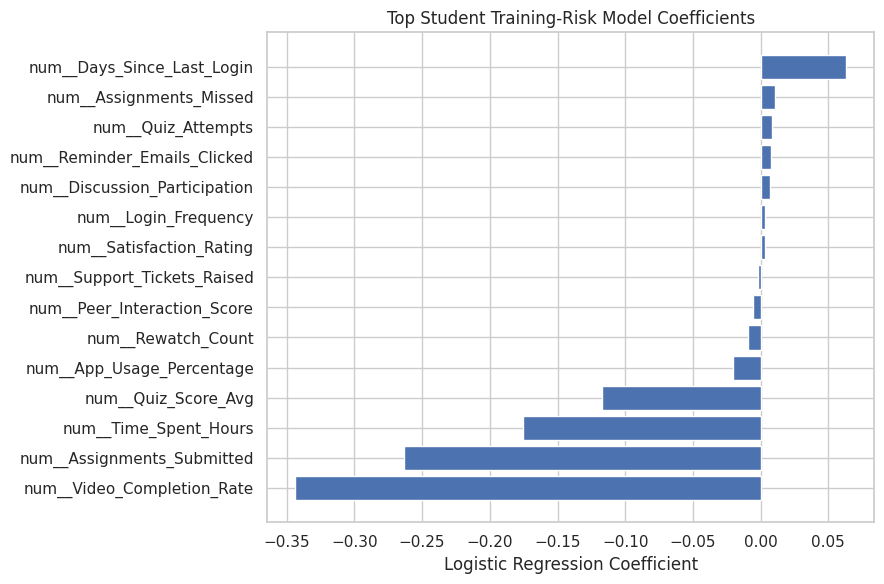

In [14]:
# Logistic Regression coefficients
feature_names = (
    student_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    student_model
    .named_steps["model"]
    .coef_[0]
)

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "absolute_coefficient": np.abs(coefficients)
})

coef_df = coef_df.sort_values(
    "absolute_coefficient",
    ascending=False
)

display(coef_df.head(15))

plt.figure(figsize=(9, 6))

top_coef = coef_df.head(15).sort_values(
    "coefficient"
)

plt.barh(
    top_coef["feature"],
    top_coef["coefficient"]
)

plt.title("Top Student Training-Risk Model Coefficients")
plt.xlabel("Logistic Regression Coefficient")
plt.tight_layout()
plt.show()

## Step 9: Load and Inspect the Vehicle Maintenance Dataset

In [15]:
VEHICLE_DATA_PATH = "Vehicle Maintenance- Service Records.csv"

df_vehicles = pd.read_csv(VEHICLE_DATA_PATH)

print("Vehicle dataset shape:", df_vehicles.shape)

print("\nColumns:")
print(df_vehicles.columns.tolist())

print("\nMissing values:")
print(df_vehicles.isna().sum().sum())

print("\nService cost statistics:")
print(df_vehicles["cost"].describe().round(2))

display(df_vehicles.head())

Vehicle dataset shape: (1139, 24)

Columns:
['slno', 'vehicle_type', 'brand', 'model', 'engine_type', 'make_year', 'region', 'mileage_range', 'mileage', 'oil_filter', 'engine_oil', 'washer_plug_drain', 'dust_and_pollen_filter', 'whell_alignment_and_balancing', 'air_clean_filter', 'fuel_filter', 'spark_plug', 'brake_fluid', 'brake_and_clutch_oil', 'transmission_fluid', 'brake_pads', 'clutch', 'coolant', 'cost']

Missing values:
0

Service cost statistics:
count     1139.00
mean      5230.84
std       2191.22
min       1099.00
25%       3678.50
50%       5199.00
75%       6584.00
max      14000.00
Name: cost, dtype: float64


,slno,vehicle_type,brand,model,engine_type,make_year,region,mileage_range,mileage,oil_filter,...,air_clean_filter,fuel_filter,spark_plug,brake_fluid,brake_and_clutch_oil,transmission_fluid,brake_pads,clutch,coolant,cost
0,1,car,honda,jazz,petrol,2017,chennai,10000,11400,1,...,0,0,0,0,0,0,0,0,0,2566
1,2,car,honda,jazz,petrol,2017,chennai,10000,11453,1,...,0,0,0,0,0,0,0,0,0,2633
2,3,car,honda,jazz,petrol,2017,chennai,10000,10706,1,...,0,0,0,0,0,0,0,0,0,2643
3,4,car,honda,jazz,petrol,2017,chennai,10000,11015,1,...,0,0,0,0,0,0,0,0,0,2532
4,5,car,honda,jazz,petrol,2017,chennai,10000,10039,1,...,0,0,0,0,0,0,0,0,0,2489


## Step 10: Vehicle Feature Selection

The prediction target is `cost`.

The model estimates service cost using vehicle information and recorded service items.

Constant columns and the row identifier are excluded.

In [16]:
# Service-item columns that actually vary in the dataset.
# oil_filter and engine_oil are excluded because they are always 1.

SERVICE_FEATURES = [
    "washer_plug_drain",
    "dust_and_pollen_filter",
    "whell_alignment_and_balancing",
    "air_clean_filter",
    "fuel_filter",
    "spark_plug",
    "brake_fluid",
    "brake_and_clutch_oil",
    "transmission_fluid",
    "brake_pads",
    "clutch",
    "coolant"
]

VEHICLE_FEATURES = [
    "brand",
    "model",
    "engine_type",
    "make_year",
    "region",
    "mileage_range",
    "mileage"
] + SERVICE_FEATURES

VEHICLE_CATEGORICAL = [
    "brand",
    "model",
    "engine_type",
    "region",
    "mileage_range"
]

VEHICLE_NUMERIC = [
    "make_year",
    "mileage"
] + SERVICE_FEATURES

assert all(
    col in df_vehicles.columns
    for col in VEHICLE_FEATURES
), "A required vehicle feature is missing."

X_vehicle = df_vehicles[VEHICLE_FEATURES]
y_vehicle = df_vehicles["cost"]

print("Vehicle features:", len(VEHICLE_FEATURES))
print(VEHICLE_FEATURES)

print("\nCategorical features:")
print(VEHICLE_CATEGORICAL)

print("\nNumeric features:")
print(VEHICLE_NUMERIC)

print("\nTarget:")
print("cost")

Vehicle features: 19
['brand', 'model', 'engine_type', 'make_year', 'region', 'mileage_range', 'mileage', 'washer_plug_drain', 'dust_and_pollen_filter', 'whell_alignment_and_balancing', 'air_clean_filter', 'fuel_filter', 'spark_plug', 'brake_fluid', 'brake_and_clutch_oil', 'transmission_fluid', 'brake_pads', 'clutch', 'coolant']

Categorical features:
['brand', 'model', 'engine_type', 'region', 'mileage_range']

Numeric features:
['make_year', 'mileage', 'washer_plug_drain', 'dust_and_pollen_filter', 'whell_alignment_and_balancing', 'air_clean_filter', 'fuel_filter', 'spark_plug', 'brake_fluid', 'brake_and_clutch_oil', 'transmission_fluid', 'brake_pads', 'clutch', 'coolant']

Target:
cost


## Step 11: Vehicle Service-Cost EDA

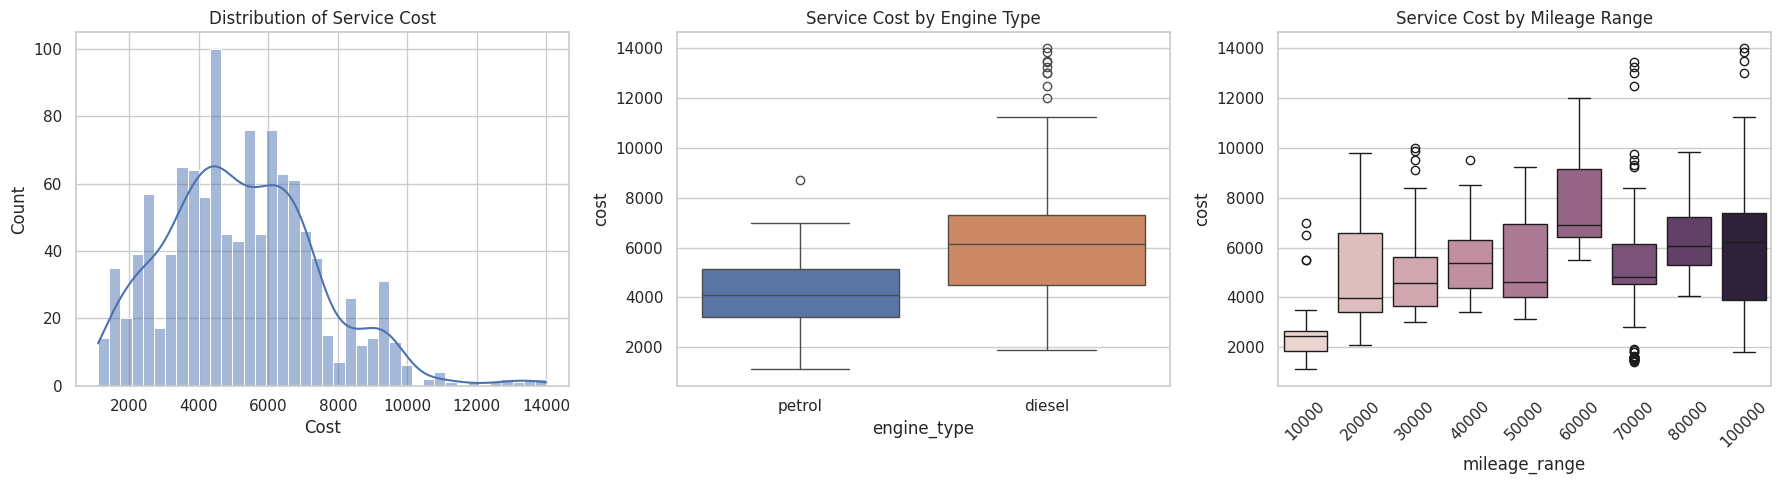

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Cost distribution
sns.histplot(
    df_vehicles["cost"],
    bins=40,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Distribution of Service Cost")
axes[0].set_xlabel("Cost")

# Cost by engine type
sns.boxplot(
    x="engine_type",
    y="cost",
    data=df_vehicles,
    hue="engine_type",
    legend=False,
    ax=axes[1]
)

axes[1].set_title("Service Cost by Engine Type")

# Cost by mileage range
order = sorted(
    df_vehicles["mileage_range"].unique()
)

sns.boxplot(
    x="mileage_range",
    y="cost",
    data=df_vehicles,
    order=order,
    hue="mileage_range",
    legend=False,
    ax=axes[2]
)

axes[2].set_title("Service Cost by Mileage Range")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Step 12: Train the Vehicle Service-Cost Regression Model

In [18]:
# ---------------------------------------------------------
# Train / test split
# ---------------------------------------------------------

X_vehicle_train, X_vehicle_test, y_vehicle_train, y_vehicle_test = (
    train_test_split(
        X_vehicle,
        y_vehicle,
        test_size=0.20,
        random_state=42
    )
)

print("Vehicle train:", X_vehicle_train.shape)
print("Vehicle test:", X_vehicle_test.shape)

# ---------------------------------------------------------
# Preprocessing
# ---------------------------------------------------------

vehicle_preprocessor = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]),
        VEHICLE_NUMERIC
    ),
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "onehot",
                OneHotEncoder(handle_unknown="ignore")
            )
        ]),
        VEHICLE_CATEGORICAL
    )
])

# ---------------------------------------------------------
# Random Forest Regression
# ---------------------------------------------------------

vehicle_model = Pipeline([
    ("preprocessor", vehicle_preprocessor),
    (
        "model",
        RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )
    )
])

vehicle_model.fit(
    X_vehicle_train,
    y_vehicle_train
)

# ---------------------------------------------------------
# Predictions
# ---------------------------------------------------------

vehicle_predictions = vehicle_model.predict(
    X_vehicle_test
)

print("\nVehicle Service-Cost Model trained successfully.")

print(
    "Example predictions:",
    np.round(vehicle_predictions[:10], 0)
)

Vehicle train: (911, 19)
Vehicle test: (228, 19)

Vehicle Service-Cost Model trained successfully.
Example predictions: [4529. 7447. 7827. 4420. 1495. 6377. 4637. 3587. 3740. 6295.]


## Step 13: Final Model Evaluation

STUDENT TRAINING-RISK MODEL
Threshold: 0.21
ROC-AUC: 0.638
Average Precision: 0.632
Precision: 0.511
Recall: 0.998
F1: 0.676

Classification Report:
              precision    recall  f1-score   support

 Not At Risk       0.77      0.01      0.01      7355
     At Risk       0.51      1.00      0.68      7645

    accuracy                           0.51     15000
   macro avg       0.64      0.50      0.34     15000
weighted avg       0.64      0.51      0.35     15000



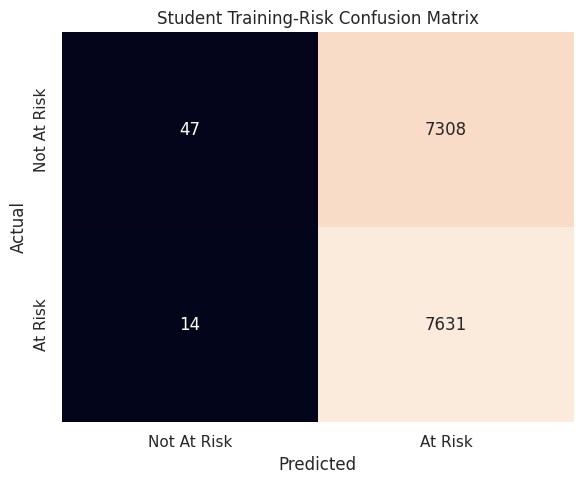



VEHICLE SERVICE-COST MODEL
Baseline MAE: 1778.92
Model MAE: 357.98
Model RMSE: 730.61
Model R²: 0.892


In [19]:
# =========================================================
# STUDENT MODEL — FINAL TEST EVALUATION
# =========================================================

test_prob = student_model.predict_proba(X_test)[:, 1]

test_pred = (
    test_prob >= RISK_THRESHOLD
).astype(int)

student_roc_auc = roc_auc_score(
    y_test,
    test_prob
)

student_ap = average_precision_score(
    y_test,
    test_prob
)

student_precision = precision_score(
    y_test,
    test_pred,
    zero_division=0
)

student_recall = recall_score(
    y_test,
    test_pred,
    zero_division=0
)

student_f1 = f1_score(
    y_test,
    test_pred,
    zero_division=0
)

print("=" * 65)
print("STUDENT TRAINING-RISK MODEL")
print("=" * 65)

print("Threshold:", round(RISK_THRESHOLD, 3))
print("ROC-AUC:", round(student_roc_auc, 3))
print("Average Precision:", round(student_ap, 3))
print("Precision:", round(student_precision, 3))
print("Recall:", round(student_recall, 3))
print("F1:", round(student_f1, 3))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        test_pred,
        target_names=["Not At Risk", "At Risk"],
        zero_division=0
    )
)

# Confusion matrix
cm = confusion_matrix(
    y_test,
    test_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cbar=False,
    xticklabels=["Not At Risk", "At Risk"],
    yticklabels=["Not At Risk", "At Risk"]
)

plt.title("Student Training-Risk Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# =========================================================
# VEHICLE MODEL — FINAL TEST EVALUATION
# =========================================================

vehicle_mae = mean_absolute_error(
    y_vehicle_test,
    vehicle_predictions
)

vehicle_rmse = np.sqrt(
    mean_squared_error(
        y_vehicle_test,
        vehicle_predictions
    )
)

vehicle_r2 = r2_score(
    y_vehicle_test,
    vehicle_predictions
)

# Simple mean baseline
vehicle_dummy = DummyRegressor(
    strategy="mean"
)

vehicle_dummy.fit(
    X_vehicle_train,
    y_vehicle_train
)

dummy_predictions = vehicle_dummy.predict(
    X_vehicle_test
)

dummy_mae = mean_absolute_error(
    y_vehicle_test,
    dummy_predictions
)

print("\n")
print("=" * 65)
print("VEHICLE SERVICE-COST MODEL")
print("=" * 65)

print(
    "Baseline MAE:",
    round(dummy_mae, 2)
)

print(
    "Model MAE:",
    round(vehicle_mae, 2)
)

print(
    "Model RMSE:",
    round(vehicle_rmse, 2)
)

print(
    "Model R²:",
    round(vehicle_r2, 3)
)

## Step 14: Vehicle Model Feature Importance

Top features affecting predicted service cost:


,feature,importance
1,num__mileage,0.389021
29,cat__mileage_range_60000,0.053223
0,num__make_year,0.048110
10,num__transmission_fluid,0.045765
16,cat__model_amaze,0.044141
22,cat__region_chennai,0.038015
21,cat__engine_type_petrol,0.037855
23,cat__region_mumbai,0.035576
20,cat__engine_type_diesel,0.034320
12,num__clutch,0.027106


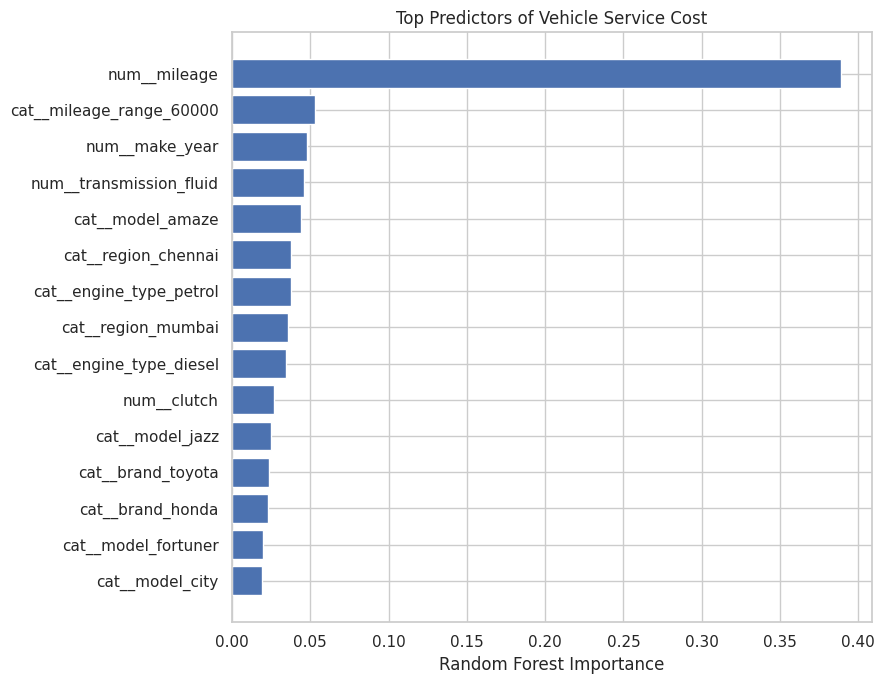

In [20]:
feature_names = (
    vehicle_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

feature_importances = (
    vehicle_model
    .named_steps["model"]
    .feature_importances_
)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importances
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

print("Top features affecting predicted service cost:")
display(importance_df.head(20))

plt.figure(figsize=(9, 7))

top_features = (
    importance_df
    .head(15)
    .sort_values("importance")
)

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.title("Top Predictors of Vehicle Service Cost")
plt.xlabel("Random Forest Importance")

plt.tight_layout()
plt.show()

## Step 15: Save Models for Backend Integration

In [21]:
# ---------------------------------------------------------
# Model metadata
# ---------------------------------------------------------

student_metadata = {
    "model_type": "LogisticRegression",
    "task": "training_completion_risk",
    "target": "At_Risk",
    "target_definition": "1 = Not Completed, 0 = Completed",
    "features": RISK_FEATURES,
    "risk_threshold": RISK_THRESHOLD,
    "version": "p6c-student-risk-v1",
    "fallback": "training_risk_baseline"
}

vehicle_metadata = {
    "model_type": "RandomForestRegressor",
    "task": "vehicle_service_cost_prediction",
    "target": "cost",
    "features": VEHICLE_FEATURES,
    "version": "p6c-vehicle-cost-v1"
}

# ---------------------------------------------------------
# Save individual models
# ---------------------------------------------------------

joblib.dump(
    student_model,
    "student_risk_model.pkl"
)

joblib.dump(
    vehicle_model,
    "vehicle_service_cost_model.pkl"
)

# ---------------------------------------------------------
# Save complete prediction suite
# ---------------------------------------------------------

prediction_suite = {
    "student": {
        "at_risk_model": student_model,
        "metadata": student_metadata
    },
    "vehicle": {
        "service_cost_model": vehicle_model,
        "metadata": vehicle_metadata
    }
}

joblib.dump(
    prediction_suite,
    "prediction_suite.pkl"
)

print("Models saved successfully:")
print(" - student_risk_model.pkl")
print(" - vehicle_service_cost_model.pkl")
print(" - prediction_suite.pkl")

print("\nStudent model features:", len(RISK_FEATURES))
print("Vehicle model features:", len(VEHICLE_FEATURES))
print("Student threshold:", round(RISK_THRESHOLD, 3))

Models saved successfully:
 - student_risk_model.pkl
 - vehicle_service_cost_model.pkl
 - prediction_suite.pkl

Student model features: 17
Vehicle model features: 19
Student threshold: 0.21


## Step 16: Backend Contract & Smoke Test

In [22]:
# Load the exact bundle that the backend will use
suite = joblib.load("prediction_suite.pkl")


# =========================================================
# STUDENT API EXAMPLE
# =========================================================

new_student = pd.DataFrame([{
    "Login_Frequency": 4,
    "Average_Session_Duration_Min": 25,
    "Video_Completion_Rate": 45.0,
    "Discussion_Participation": 1,
    "Time_Spent_Hours": 1.5,
    "Days_Since_Last_Login": 10,
    "Notifications_Checked": 3,
    "Peer_Interaction_Score": 4.5,
    "Assignments_Submitted": 3,
    "Assignments_Missed": 7,
    "Quiz_Attempts": 2,
    "Quiz_Score_Avg": 60.0,
    "Rewatch_Count": 1,
    "App_Usage_Percentage": 50,
    "Reminder_Emails_Clicked": 1,
    "Support_Tickets_Raised": 2,
    "Satisfaction_Rating": 3.5
}])

student_pipe = suite["student"]["at_risk_model"]

student_probability = student_pipe.predict_proba(
    new_student
)[0, 1]

student_prediction = int(
    student_probability >= suite["student"]["metadata"]["risk_threshold"]
)

print("=" * 60)
print("STUDENT PREDICTION")
print("=" * 60)

print(
    "Risk probability:",
    round(student_probability, 3)
)

print(
    "At-risk prediction:",
    student_prediction
)


# =========================================================
# VEHICLE API EXAMPLE
# =========================================================

new_vehicle = pd.DataFrame([{
    "brand": "honda",
    "model": "jazz",
    "engine_type": "petrol",
    "make_year": 2017,
    "region": "chennai",
    "mileage_range": "60k",
    "mileage": 58000,

    "washer_plug_drain": 1,
    "dust_and_pollen_filter": 0,
    "whell_alignment_and_balancing": 0,
    "air_clean_filter": 1,
    "fuel_filter": 0,
    "spark_plug": 0,
    "brake_fluid": 0,
    "brake_and_clutch_oil": 0,
    "transmission_fluid": 0,
    "brake_pads": 1,
    "clutch": 0,
    "coolant": 0
}])

vehicle_pipe = suite["vehicle"]["service_cost_model"]

predicted_cost = vehicle_pipe.predict(
    new_vehicle
)[0]

print("\n")
print("=" * 60)
print("VEHICLE PREDICTION")
print("=" * 60)

print(
    "Estimated service cost:",
    round(float(predicted_cost), 2)
)

STUDENT PREDICTION
Risk probability: 0.706
At-risk prediction: 1


VEHICLE PREDICTION
Estimated service cost: 3758.42


## Step 17: Final Model Summary

The notebook contains two independent prediction tasks.

### Model 1 — Student Training Completion Risk
- Dataset: Course_Completion_Prediction.csv
- Task: Binary classification
- Target: At_Risk
- Model: Logistic Regression
- Features: learning/activity behaviour
- Evaluation: ROC-AUC, Average Precision, Precision, Recall, F1
- Fallback: deterministic training-risk rules

### Model 2 — Vehicle Service Cost
- Dataset: Vehicle Maintenance- Service Records.csv
- Task: Regression
- Target: cost
- Model: Random Forest Regressor
- Evaluation: MAE, RMSE, R²
- Output: estimated service cost

The two datasets are kept separate because they represent different populations and different prediction tasks.

In [23]:
print("=" * 70)
print("P6-C MODEL SUMMARY")
print("=" * 70)

print("\nSTUDENT MODEL")
print("-" * 70)
print("Task: Training Completion Risk")
print("Model: Logistic Regression")
print("Features:", len(RISK_FEATURES))
print("Threshold:", round(RISK_THRESHOLD, 3))
print("ROC-AUC:", round(student_roc_auc, 3))
print("Average Precision:", round(student_ap, 3))
print("Precision:", round(student_precision, 3))
print("Recall:", round(student_recall, 3))
print("F1:", round(student_f1, 3))

print("\nVEHICLE MODEL")
print("-" * 70)
print("Task: Vehicle Service Cost Prediction")
print("Model: Random Forest Regressor")
print("Features:", len(VEHICLE_FEATURES))
print("Baseline MAE:", round(dummy_mae, 2))
print("Model MAE:", round(vehicle_mae, 2))
print("Model RMSE:", round(vehicle_rmse, 2))
print("Model R²:", round(vehicle_r2, 3))

print("\nSAVED FILES")
print("-" * 70)
print("student_risk_model.pkl")
print("vehicle_service_cost_model.pkl")
print("prediction_suite.pkl")

print("\nNotebook completed successfully.")

P6-C MODEL SUMMARY

STUDENT MODEL
----------------------------------------------------------------------
Task: Training Completion Risk
Model: Logistic Regression
Features: 17
Threshold: 0.21
ROC-AUC: 0.638
Average Precision: 0.632
Precision: 0.511
Recall: 0.998
F1: 0.676

VEHICLE MODEL
----------------------------------------------------------------------
Task: Vehicle Service Cost Prediction
Model: Random Forest Regressor
Features: 19
Baseline MAE: 1778.92
Model MAE: 357.98
Model RMSE: 730.61
Model R²: 0.892

SAVED FILES
----------------------------------------------------------------------
student_risk_model.pkl
vehicle_service_cost_model.pkl
prediction_suite.pkl

Notebook completed successfully.
